In [ ]:
# @title 1. Instalación de Librerías y Montaje de Drive
!pip install transformers torch pandas matplotlib seaborn pyarrow ftfy nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
from google.colab import drive

# Descargar recursos de NLTK
nltk.download('stopwords')
nltk.download('punkt')

# Montar Google Drive
drive.mount('/content/drive')

print("Entorno configurado.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Mounted at /content/drive
Entorno configurado.


In [ ]:
import pandas as pd
import unicodedata
from collections import Counter
from pathlib import Path
import string

# --- CONFIGURACIÓN ---
file_path = Path("/content/drive/MyDrive/Proyecto Final MIR/aligned_metadata.csv")
col_name = 'lyrics'

def detectar_anomalias_estrictas(path, column):
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"❌ Error: No se encuentra el archivo en: {path}")
        return

    print("⏳ Procesando texto...")
    # Convertimos a string y unimos
    all_text = "".join(df[column].dropna().astype(str).tolist())
    conteo = Counter(all_text)

    anomalies_data = []

    # Definimos la "Lista Blanca" (Lo que es aceptable en inglés puro)
    # ascii_letters = a-z y A-Z
    # También incluimos espacio, saltos de línea y las comillas simples/dobles estándar
    allowed_chars = set(string.ascii_letters + " \n\r'\"")

    for char, freq in conteo.items():
        # --- FILTRO ---
        # Si el caracter está en la lista blanca, NO lo reportamos (continue)
        if char in allowed_chars:
            continue

        # Si llegamos aquí, es una "Anomalía" según tus criterios
        try:
            name = unicodedata.name(char)
        except ValueError:
            name = "UNKNOWN"

        category = unicodedata.category(char)

        # --- CLASIFICACIÓN ---
        tipo = "Otro Símbolo"

        # 1. Detectar Español / Acentos (Latinos que no son ASCII)
        if "LATIN" in name:
            tipo = "Acento/Español (á, ñ, etc)"

        # 2. Detectar Números
        elif category.startswith("N"):
            tipo = "Número"

        # 3. Detectar Asiáticos
        elif "CJK" in name or "HIRAGANA" in name or "KATAKANA" in name or "HANGUL" in name:
            tipo = "ASIÁTICO (Japonés/Coreano/Chino)"

        # 4. Paréntesis y Puntuación varia (., ?, !, -)
        elif category.startswith("P"):
            if char in "()[]{}":
                tipo = "Paréntesis/Corchetes"
            else:
                tipo = "Puntuación extra (.,?!-)"

        # 5. Emojis
        elif "EMOJI" in name or category == "So":
            tipo = "Emoji/Gráfico"

        code_point = f"U+{ord(char):04X}"

        # Ajuste visual para caracteres invisibles
        char_visual = char
        if char == "\t": char_visual = "[TAB]"

        anomalies_data.append({
            "Carácter": char_visual,
            "Frecuencia": freq,
            "Tipo": tipo,
            "Unicode Name": name,
            "Code Point": code_point
        })

    # Crear DataFrame
    df_anomalias = pd.DataFrame(anomalies_data)

    if df_anomalias.empty:
        print("\n✅ ¡Increíble! El dataset es 100% Inglés puro (A-Z) y limpio.")
        return

    # Ordenar por frecuencia
    df_anomalias = df_anomalias.sort_values(by="Frecuencia", ascending=False).reset_index(drop=True)

    # --- REPORTE ---
    print(f"\n🔍 Se encontraron {len(df_anomalias)} caracteres que NO son inglés básico.")

    print("\n--- Resumen por Categoría ---")
    print(df_anomalias['Tipo'].value_counts())

    print("\n--- Top 60 Caracteres a Limpiar ---")
    # Estilizamos para alinear a la izquierda
    display(df_anomalias.head(60).style.set_properties(**{'text-align': 'left'}))

# Ejecutar
detectar_anomalias_estrictas(file_path, col_name)

❌ Error: No se encuentra el archivo en: /content/drive/MyDrive/Proyecto Final MIR/aligned_metadata.csv


In [ ]:
# @title 2. Carga y Fusión de Datos (Lyrics + Metadata)
from pathlib import Path

# --- RUTAS A TUS ARCHIVOS (AJÚSTALAS) ---
# Ruta del archivo que generaste con el pipeline de texto (Parquet)
LYRICS_PATH = Path("/content/drive/MyDrive/Proyecto Final MIR/data/processed/features_1d/lyrics_cleaned.parquet")

# Ruta del archivo que tiene los cuadrantes (CSV)
METADATA_PATH = Path("/content/drive/MyDrive/Proyecto Final MIR/data/interim/aligned_metadata.csv")

# 1. Cargar Letras
print("Cargando letras...")
if LYRICS_PATH.suffix == '.parquet':
    df_lyrics = pd.read_parquet(LYRICS_PATH)
else:
    df_lyrics = pd.read_csv(LYRICS_PATH)

# 2. Cargar Metadatos (Solo necesitamos ID y Cuadrante)
print("label Cargando etiquetas...")
df_meta = pd.read_csv(METADATA_PATH)

# Asegurarnos de que el nombre de la columna de ID sea igual en ambos
# Si en uno es 'musicId' y en otro 'spotify_id', renombra aquí:
if 'musicId' in df_meta.columns and 'spotify_id' and 'artist' and 'track_name' not in df_meta.columns:
    df_meta.rename(columns={'musicId': 'spotify_id','artist':'artist','track_name':'name'}, inplace=True)

# 3. MERGE (Cruce)
# Usamos 'inner' para quedarnos solo con canciones que tengan AMBAS cosas (Letra y Etiqueta)
print("Cruzando tablas por 'spotify_id'...")

# Seleccionamos solo las columnas necesarias del metadata para no ensuciar
cols_meta = ['spotify_id', 'label_quadrant','valence','arousal','artist','track_name'] # Agrega 'valence', 'arousal' si quieres graficarlos
df = pd.merge(df_lyrics, df_meta[cols_meta], on='spotify_id', how='inner')

print(f"\n Dataset Unificado: {df.shape[0]} canciones.")
print("Columnas disponibles:", df.columns.tolist())
df.head(100)

Cargando letras...
label Cargando etiquetas...
Cruzando tablas por 'spotify_id'...

 Dataset Unificado: 6455 canciones.
Columnas disponibles: ['spotify_id', 'clean_lyrics_tfidf', 'clean_lyrics_bert', 'label_quadrant', 'valence', 'arousal', 'artist', 'track_name']


,spotify_id,clean_lyrics_tfidf,clean_lyrics_bert,label_quadrant,valence,arousal,artist,track_name
0,1w8r3PAxPPLfcuyRsC4BeA,wanted stay away wanted run hide vows promises...,What if I wanted to stay away?\nWhat if I want...,Q2_Angry,0.225,0.858,Elysion,Made of Lies
1,6VeihScj0pNr6uGFxfzalq,gamble double dont step want stay youre bold r...,"It's a gamble, double down or don't\nStep out ...",Q2_Angry,0.327,0.976,Hot Water Music,Wayfarer
2,6HfUriaVuymw9EmYeG9WH5,could give life would take chance make see muc...,If I could give you life I would take the chan...,Q2_Angry,0.392,0.651,Grinspoon,Bleed You Dry
3,2zEcAdsl5OjxKRrGQA5Z49,save breath dont waste time ive got nothing le...,Save your breath\nDon't waste your time on me\...,Q2_Angry,0.200,0.932,VRSTY,Wilt
4,0mJUxFpEI1eAOIIfnNoZ4G,im waiting cold cell bell begins chime reflect...,I'm waiting in my cold cell when the bell begi...,Q2_Angry,0.225,0.972,Cradle Of Filth,Hallowed Be Thy Name
...,...,...,...,...,...,...,...,...
95,09MDUuCWmLV73BK0uGZVgR,wanna see hands ive watchin like see wont plea...,I wanna see some hands\nIve been watchin you f...,Q2_Angry,0.364,0.956,The Carburetors,"Allright, Allright"
96,2CPturRUlpvirYr7VpkXCV,aint hard tell excel prevail mic contacted att...,"It ain't hard to tell, I excel, then prevail\n...",Q2_Angry,0.357,0.729,Nas,It Ain't Hard to Tell
97,4e9eGQYsOiBcftrWXwsVco,life waterfall one river one fall swimming voi...,Life is a waterfall\nWe're one in the river an...,Q2_Angry,0.227,0.922,System Of A Down,Aerials
98,4Ir2UxDlAm01qmv3eSZYlP,stuck afterglow afterglow afterglow stuck afte...,"Stuck in the afterglow, afterglow, afterglow\n...",Q2_Angry,0.236,0.673,Nils Hoffmann,Afterglow


Generando nubes de palabras para títulos ('track_name') eliminando stopwords...


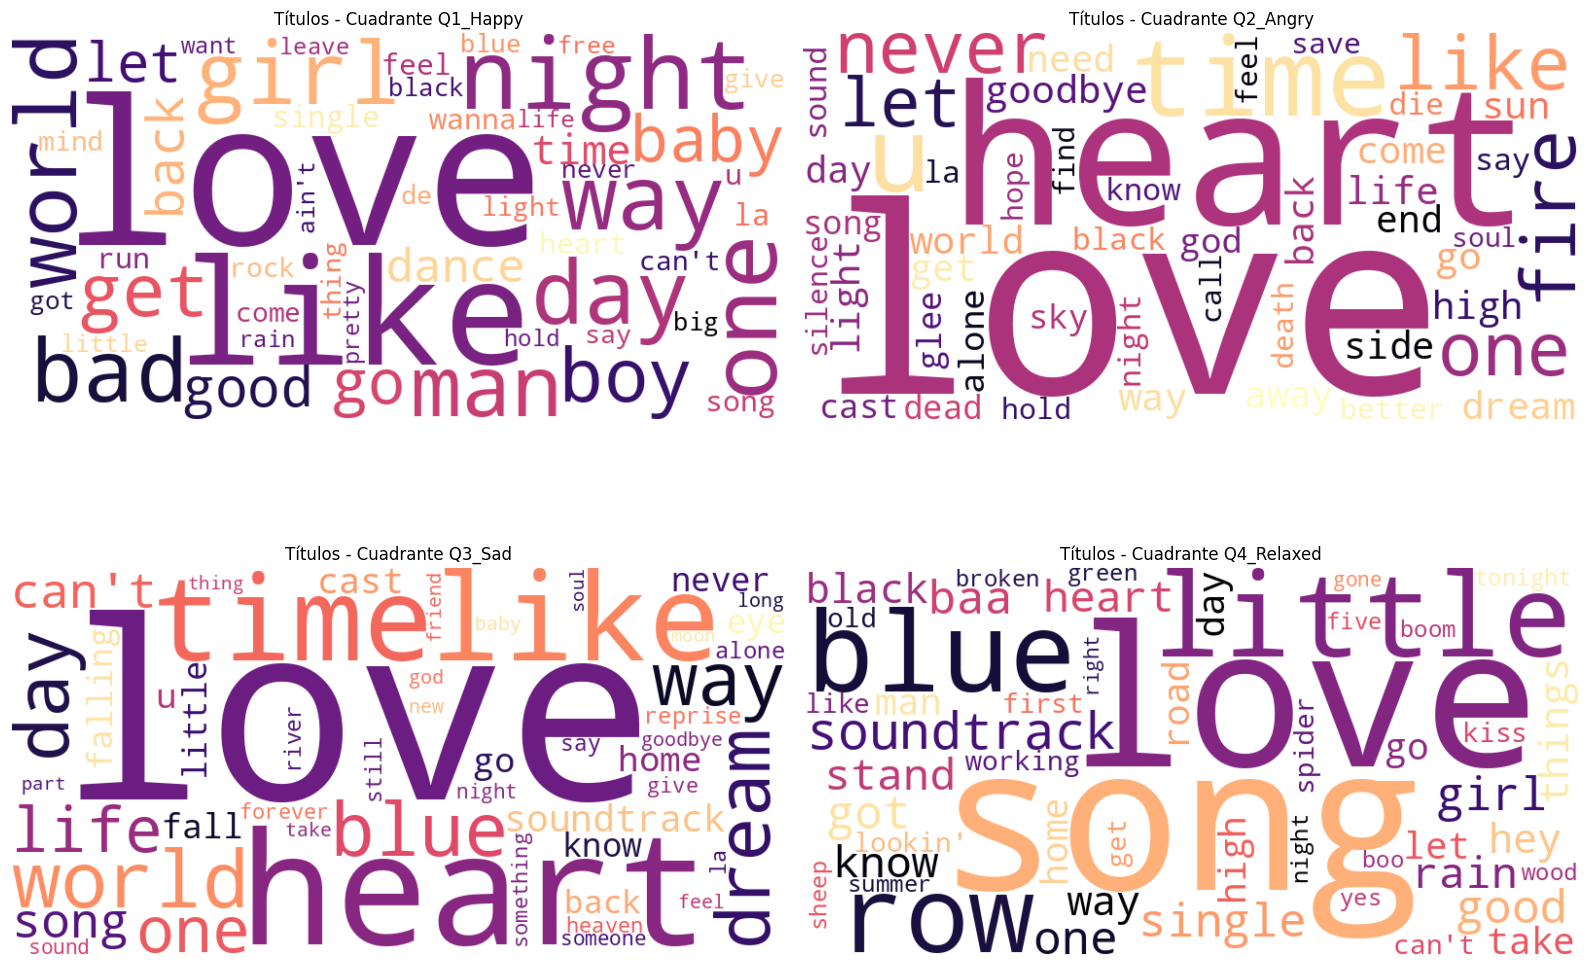

In [ ]:
# @title 2.1. Análisis de Títulos de Canciones (WordClouds) - Sin Stopwords
from wordcloud import WordCloud
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

# 1. Detectar nombre de la columna de título
title_col = 'track_name' if 'track_name' in df.columns else 'name'
if title_col not in df.columns:
    print(f"No encuentro la columna de título. Columnas disponibles: {df.columns.tolist()}")

# 2. Configuración de Stopwords para Títulos
#    A. Stopwords estándar del inglés (the, a, and, of...)
english_stops = set(stopwords.words('english'))

#    B. Palabras genéricas de la industria musical
music_stops = {'feat', 'ft', 'remix', 'edit', 'version', 'remastered', 'live', 'mix', 'radio', 'acoustic', 'original', 'extended','remaster'}

#    C. UNIÓN: Juntamos ambas listas
combined_title_stops = english_stops.union(music_stops)

def clean_title_for_wc(text):
    if not isinstance(text, str): return ""
    return text.lower()

# 3. Generación de WordClouds
quadrants = sorted(df['label_quadrant'].unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Mapeo de nombres para el título (Opcional, para mayor claridad)
quad_names = {
    0: 'Q0: Happy (+Val, +Aro)',
    1: 'Q1: Angry (-Val, +Aro)',
    2: 'Q2: Sad (-Val, -Aro)',
    3: 'Q3: Relaxed (+Val, -Aro)'
}

print(f"Generando nubes de palabras para títulos ('{title_col}') eliminando stopwords...")

for i, quad in enumerate(quadrants):
    subset = df[df['label_quadrant'] == quad]

    # Unir todos los títulos en un solo texto gigante
    text = " ".join(subset[title_col].fillna("").apply(clean_title_for_wc))

    # Crear WordCloud
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=combined_title_stops,  # <--- AQUÍ USAMOS LA LISTA COMBINADA
        colormap='magma',
        max_words=50,
        collocations=False # Evita que se repitan palabras dobles si no aportan mucho
    ).generate(text)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')

    # Título dinámico
    title_text = quad_names.get(quad, f'Cuadrante {quad}')
    axes[i].set_title(f'Títulos - {title_text}')

plt.tight_layout()
plt.show()

Analizando artistas ('artist')...


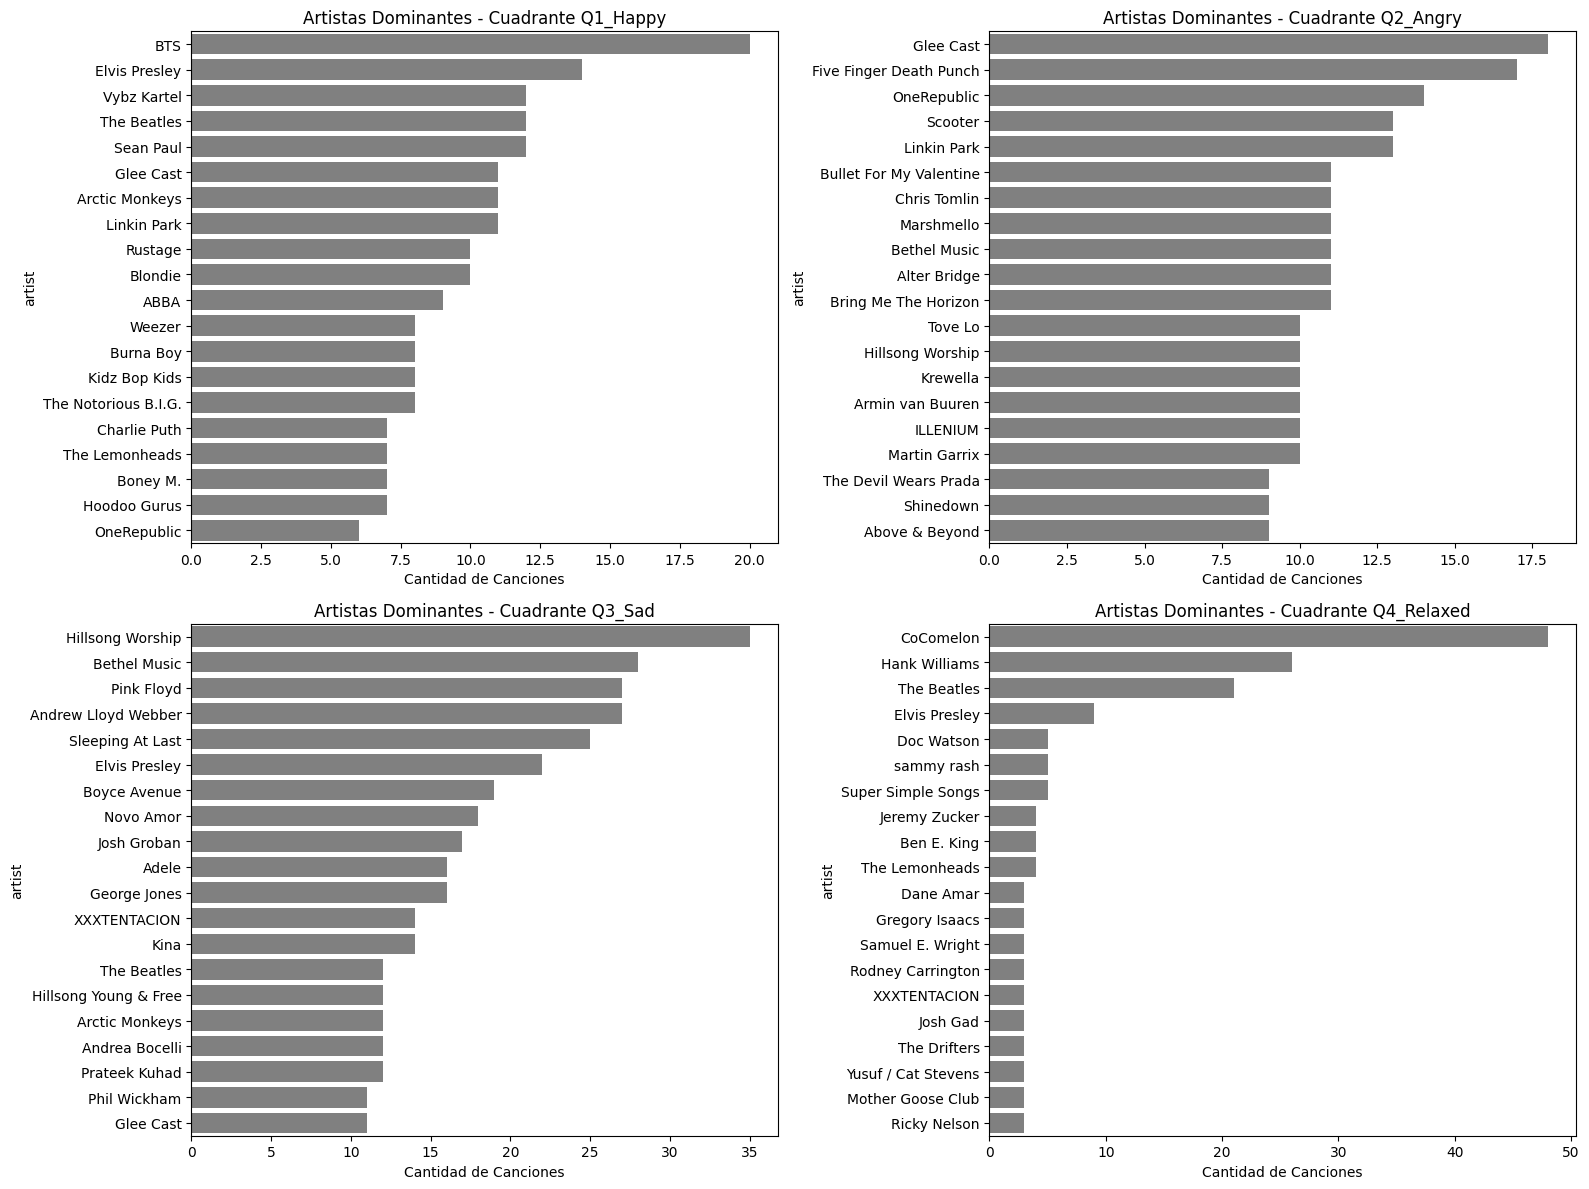

In [ ]:
# @title 2.2. Top 10 Artistas por Cuadrante Emocional

# 1. Detectar nombre de columna de artista
artist_col = 'artist_name' if 'artist_name' in df.columns else 'artist'
if artist_col not in df.columns:
    print(f" No encuentro columna de artista. Columnas: {df.columns.tolist()}")
    # artist_col = 'tu_columna_artista'

# 2. Configurar Gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = {0: 'gold', 1: 'crimson', 2: 'navy', 3: 'forestgreen'}

print(f"Analizando artistas ('{artist_col}')...")

for i, quad in enumerate(sorted(df['label_quadrant'].unique())):
    subset = df[df['label_quadrant'] == quad]

    # Contar artistas
    # (Si hay varios artistas separados por comas, tomamos el principal o la cadena completa)
    top_artists = subset[artist_col].value_counts().head(20)

    sns.barplot(
        x=top_artists.values,
        y=top_artists.index,
        ax=axes[i],
        color=colors.get(quad, 'gray')
    )

    axes[i].set_title(f'Artistas Dominantes - Cuadrante {quad}')
    axes[i].set_xlabel('Cantidad de Canciones')

plt.tight_layout()
plt.show()

#print("\nQUÉ BUSCAR EN ESTAS GRÁFICAS:")
#print("1. Dominancia Excesiva: Si un solo artista tiene más del 10-15% de las canciones del cuadrante, es un riesgo de sesgo.")
#print("   (Ej: Si Taylor Swift es el 30% de tu clase 'Sad', el modelo aprenderá 'Taylor Swift = Sad').")
#print("2. Coherencia: ¿Tiene sentido que estos artistas estén ahí? (Ej. Metallica en Angry, Bob Marley en Relaxed).")

In [ ]:
# @title 2.3 Exploración Visual: Tabla de Muestras por Emoción
from IPython.display import display, Markdown

print(df.head())

# 1. Configuración de Columnas
col_artist = 'artist_name' if 'artist_name' in df.columns else 'artist'
col_track = 'track_name' if 'track_name' in df.columns else 'name'
col_quad = 'quadrant' if 'quadrant' in df.columns else 'label_quadrant'

# Intentamos usar la letra limpia con estructura (BERT) para que sea legible
col_lyrics = 'clean_lyrics_bert'

# 2. Diccionario de Emociones
emotion_map = {
    0: 'Q0: HAPPY / ENERGETIC (+Valence, +Arousal)',
    1: 'Q1: ANGRY / AGGRESSIVE (-Valence, +Arousal)',
    2: 'Q2: SAD / DEPRESSIVE (-Valence, -Arousal)',
    3: 'Q3: RELAXED / CALM (+Valence, -Arousal)'
}

print(f"Mostrando muestra aleatoria de canciones con letra...\n")

# 3. Iterar y Mostrar
unique_quads = sorted(df[col_quad].unique())

for q in unique_quads:
    subset = df[df[col_quad] == q]

    n_samples = min(15, len(subset))
    if n_samples > 0:
        # Tomamos muestra
        samples = subset.sample(n=n_samples, random_state=42).copy()

        # --- CREAR VISTA PREVIA DE LETRA ---
        # Tomamos los primeros 250 caracteres y agregamos "..."
        samples['Lyrics Preview'] = samples[col_lyrics].fillna("").astype(str).apply(
            lambda x: x[:250].replace('\n', ' / ') + "..." if len(x) > 250 else x
        )

        # Seleccionamos columnas para mostrar
        cols_to_show = [col_artist, col_track, col_quad, 'Lyrics Preview']

        # Mostrar
        display(Markdown(f"### {emotion_map.get(q, f'Cuadrante {q}')}"))
        display(samples[cols_to_show])
        print("\n" + "-"*80 + "\n")
    else:
        print(f"⚠️ No hay datos para el cuadrante {q}")

               spotify_id                                 clean_lyrics_tfidf  \
0  1w8r3PAxPPLfcuyRsC4BeA  wanted stay away wanted run hide vows promises...   
1  6VeihScj0pNr6uGFxfzalq  gamble double dont step want stay youre bold r...   
2  6HfUriaVuymw9EmYeG9WH5  could give life would take chance make see muc...   
3  2zEcAdsl5OjxKRrGQA5Z49  save breath dont waste time ive got nothing le...   
4  0mJUxFpEI1eAOIIfnNoZ4G  im waiting cold cell bell begins chime reflect...   

                                   clean_lyrics_bert label_quadrant  valence  \
0  What if I wanted to stay away?\nWhat if I want...       Q2_Angry    0.225   
1  It's a gamble, double down or don't\nStep out ...       Q2_Angry    0.327   
2  If I could give you life I would take the chan...       Q2_Angry    0.392   
3  Save your breath\nDon't waste your time on me\...       Q2_Angry    0.200   
4  I'm waiting in my cold cell when the bell begi...       Q2_Angry    0.225   

   arousal           artist           

### Cuadrante Q1_Happy

,artist,track_name,label_quadrant,Lyrics Preview
4190,Vishal-Shekhar,Ishq Bulaava,Q1_Happy,Ishq bulava aave jab aave.. / Main ta kol tere...
4407,OH MY GIRL,Nonstop,Q1_Happy,"Oh, no / Yeah, yeah / Going nonstop / Ooh-na-n..."
5454,MindaRyn,Like Flames,Q1_Happy,Fate repeats all over again / The voices of my...
5302,The Jacksons,"Can You Feel It - 7"" Version",Q1_Happy,"Can you feel it, can you feel it, can you feel..."
4431,Ashnikko,Daisy,Q1_Happy,"You don't wanna see me bratty / Pet the kitty,..."
5329,Bella Poarch,Villain,Q1_Happy,"I don't know why I'm like this, I'd love to pi..."
4930,Hoodoo Gurus,A Place In The Sun - 2005 Remaster,Q1_Happy,"Hey, girl - it's a new world, let's have a lit..."
5334,KRS-One,Step into a World (Rapture's Delight),Q1_Happy,unlisted bonus track on compact disc / / I'mm...
5294,Sideline,Return To Windy Mountain,Q1_Happy,"Well I was born on Windy Mountain / Bramwell, ..."
5089,The Black Keys,Your Touch,Q1_Happy,And I want / And you got it / So much / I'm cr...



--------------------------------------------------------------------------------



### Cuadrante Q2_Angry

...

,artist,track_name,label_quadrant,Lyrics Preview
2203,Louis Armstrong,Dream A Little Dream Of Me,Q3_Sad,Stars shining bright above you / Night breezes...
3508,Judy Kuhn,"Colors of the Wind - From ""Pocahontas""",Q3_Sad,You think I'm an ignorant savage / And you've ...
2776,Adele,Woman Like Me,Q3_Sad,"You're driving me away, give me a reason to st..."
3166,Arctic Monkeys,Mr Schwartz,Q3_Sad,Put your heavy metal to the test / There might...
3751,Arctic Monkeys,The Car,Q3_Sad,Your grandfather's guitar / Thinkin' about how...
2476,Colin & Caroline,Let It Go,Q3_Sad,From walking home and talking loads / To seein...
2922,Andrew Lloyd Webber,Finale,Q3_Sad,"Control, control\nRace time, minus one minute\..."
3578,Stephen Lynch,Pierre,Q3_Sad,I got a call from my old writing partner from ...
3277,Lea Salonga,"Reflection - From ""Mulan"" / Soundtrack Version",Q3_Sad,"Look at me, I will never pass for a perfect br..."
3103,Phil Wickham,"1,000 Names - Acoustic",Q3_Sad,I call You Maker / You give life an eternal sp...



--------------------------------------------------------------------------------



### Cuadrante Q4_Relaxed

,artist,track_name,label_quadrant,Lyrics Preview
6416,Paycheck,LOSING INTEREST,Q4_Relaxed,"Losing Interest, you won't find no better than..."
6048,Heidi Blickenstaff,I Am Playing Me,Q4_Relaxed,I'm standing here / Just left of center and / ...
6398,Charlie Walker,Pick Me up on Your Way Down,Q4_Relaxed,You were mine for just awhile / Now you're put...
6438,CoComelon,Happy Birthday Song,Q4_Relaxed,Happy birthday to you\nHappy birthday to you\n...
6392,The Doors,Five to One - 2018 Remaster,Q4_Relaxed,"Yeah, c'mon / I love my girl / She lookin' goo..."
6276,Elvis Presley,I Got Lucky,Q4_Relaxed,Never found a four leaf clover / To bring good...
5994,Dane Amar,PCH,Q4_Relaxed,"You're like a top down, sunset, on a good day ..."
6184,Hank Williams,"Hey, Good Lookin'",Q4_Relaxed,"Say hey, good lookin' - what ya got cookin'? /..."
6448,The Beatles,For No One - Remastered 2009,Q4_Relaxed,"Your day breaks, your mind aches / You find th..."
6195,Damien,i can't stop,Q4_Relaxed,"No, you can't break me now-ow / / I stopped s..."



--------------------------------------------------------------------------------



Agrupando textos por clase...
Generando rankings TF-IDF...


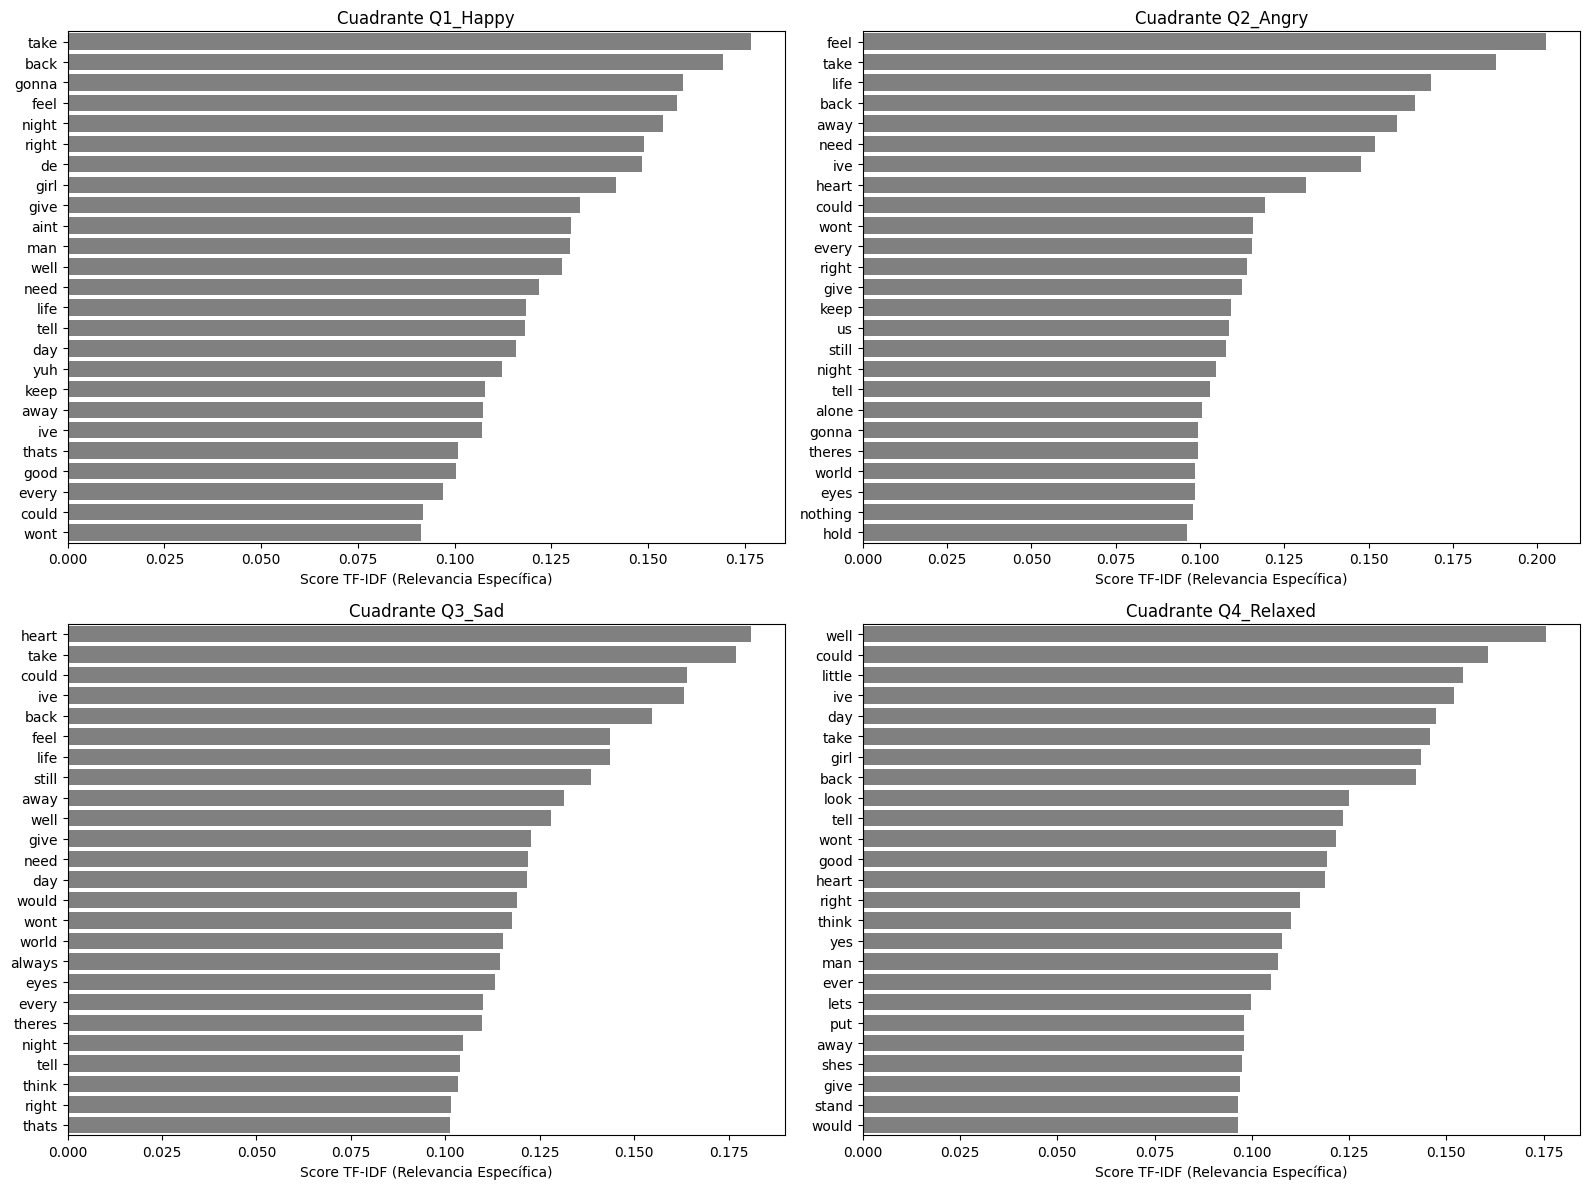

In [ ]:
# @title 2.4 Palabras más Representativas por Cuadrante (c-TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Configuración de Stopwords (La lista robusta que definimos antes)
#    Es crucial aquí para que 'yeah' no sea la palabra más importante de 'Happy'.
import nltk
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

music_noise_words = {
    # Contracciones informales comunes
    'im', 'em', 'cause',

    # Palabras comunes de relleno (Bajo valor semántico en exceso)
    'know', 'like', 'yeah', 'oh', 'got', 'go', 'get', 'just', 'na',
    'baby', 'see', 'let', 'make', 'say', 'time', 'come', 'one', 'want',
    'run', 'yet', # Agregadas las bases de tus bigramas

    # Interjecciones y sonidos vocales (Ruido puro)
    'la', 'ooh', 'ah', 'doo', 'hey', 'eh', 'woah', 'whoa', 'ha', 'mmm',
    'dum', 'pam', 'da', 'uh', 'ba', 'ya', 'pa', 'yo', 'bam', 'boom', 'um', 'tit', 'sir',
    'shake', 'bum', 'hmm', 'huh', 'cha', 'lala','mm','nah', 'wow',"dont","love","ill",
    "never", "never","cant","way",

    # Palabras en español filtradas (Spanglish noise)
    'que', 'tu', 'lo','mi','youre','wanna'
}

# Unimos todo
custom_stops = stop_words.union(music_noise_words)



# 2. Agrupar textos por Cuadrante
#    Creamos 4 "Documentos Gigantes", uno por emoción.
print("Agrupando textos por clase...")
grouped_df = df.groupby('label_quadrant')['clean_lyrics_tfidf'].apply(lambda x: " ".join(x.fillna("").astype(str))).reset_index()

# 3. Aplicar TF-IDF sobre estos 4 documentos
#    Si una palabra aparece en los 4 grupos (ej. "love"), su score bajará.
#    Si aparece solo en Q1 (ej. "hate"), su score subirá.
tfidf = TfidfVectorizer(stop_words=list(custom_stops), min_df=0.0) # min_df=0 para no filtrar nada en estos 4 docs
X_tfidf = tfidf.fit_transform(grouped_df['clean_lyrics_tfidf'])
feature_names = np.array(tfidf.get_feature_names_out())

# 4. Función para extraer top N palabras
def get_top_tfidf_words(row_idx, top_n=15):
    # Obtener fila del cuadrante
    row = X_tfidf[row_idx]
    # Ordenar índices por puntaje
    # (toarray lo hace denso, argsort ordena, [::-1] invierte para descendente)
    sorted_indices = np.argsort(row.toarray()).flatten()[::-1]
    top_indices = sorted_indices[:top_n]

    top_words = feature_names[top_indices]
    top_scores = row.toarray().flatten()[top_indices]
    return top_words, top_scores

# 5. Visualización
quadrants = grouped_df['label_quadrant'].values
colors = {0: 'gold', 1: 'crimson', 2: 'navy', 3: 'forestgreen'}
titles = {
    0: 'Q0: Happy (+Val, +Aro)',
    1: 'Q1: Angry (-Val, +Aro)',
    2: 'Q2: Sad (-Val, -Aro)',
    3: 'Q3: Relaxed (+Val, -Aro)'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

print("Generando rankings TF-IDF...")

for i, quad in enumerate(quadrants):
    words, scores = get_top_tfidf_words(i, top_n=25)

    sns.barplot(x=scores, y=words, ax=axes[i], color=colors.get(quad, 'gray'))
    axes[i].set_title(titles.get(quad, f'Cuadrante {quad}'))
    axes[i].set_xlabel('Score TF-IDF (Relevancia Específica)')

plt.tight_layout()
plt.show()

 Generando Bigramas... (Esto puede tardar unos segundos)


/tmp/ipython-input-2765701890.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(phrases), ax=axes[i], palette='magma')
/tmp/ipython-input-2765701890.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(phrases), ax=axes[i], palette='magma')
/tmp/ipython-input-2765701890.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(phrases), ax=axes[i], palette='magma')
/tmp/ipython-input-2765701890.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

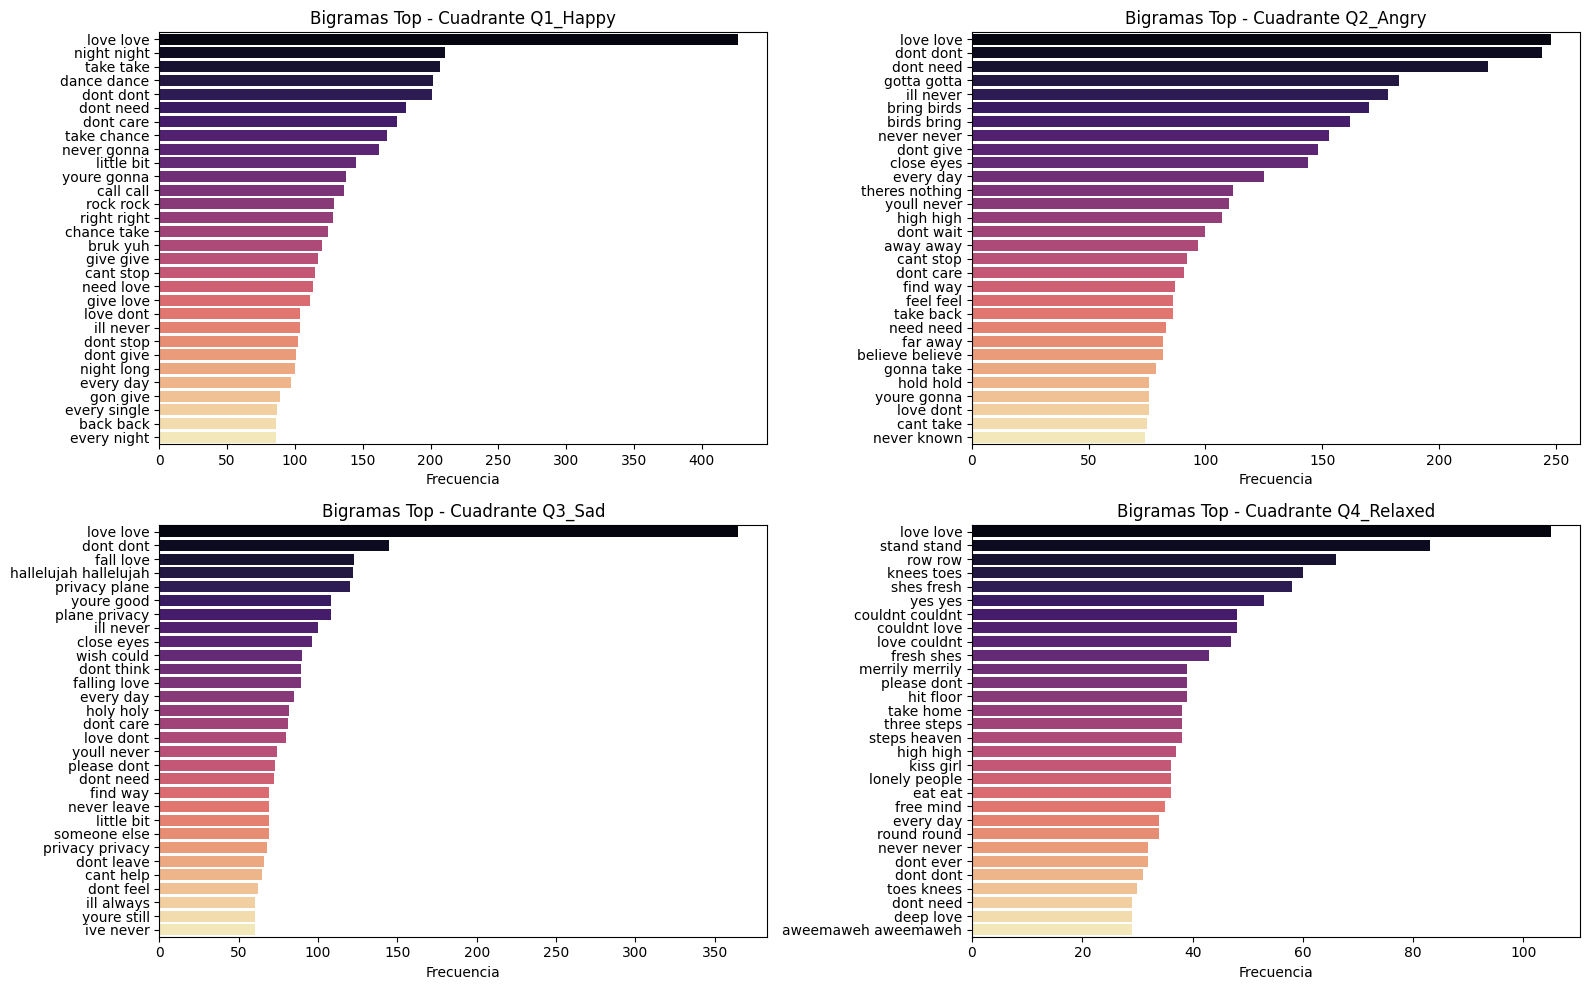

In [ ]:
# @title 2.5. Análisis de Bigramas por Cuadrante
from sklearn.feature_extraction.text import CountVectorizer

# 1. Definir Stopwords (Reusamos las del paso anterior para consistencia)
# Definición de Stopwords mejorada
stop_words = set(stopwords.words('english'))

music_noise_words = {
    # Contracciones informales comunes
    'im', 'em', 'cause',

    # Palabras comunes de relleno (Bajo valor semántico en exceso)
    'know', 'like', 'yeah', 'oh', 'got', 'go', 'get', 'just', 'na',
    'baby', 'see', 'let', 'make', 'say', 'time', 'come', 'one', 'want',
    'run', 'yet', # Agregadas las bases de tus bigramas

    # Interjecciones y sonidos vocales (Ruido puro)
    'la', 'ooh', 'ah', 'doo', 'hey', 'eh', 'woah', 'whoa', 'ha', 'mmm',
    'dum', 'pam', 'da', 'uh', 'ba', 'ya', 'pa', 'yo', 'bam', 'boom', 'um', 'tit', 'sir',
    'shake', 'bum', 'hmm', 'huh', 'cha', 'lala','mm','nah', 'wow','nana','oohooh','doodoo',
    'jhoom','mam','ohoh','ima',"wanna",

    # Palabras en español filtradas (Spanglish noise)
    'que', 'tu', 'lo','de'
}

# Unimos todo
custom_stops = stop_words.union(music_noise_words)

# NOTA: He quitado 'hallelujah' porque aporta emoción (Suele ser Q1 o Q3).

def get_top_bigrams(corpus, n=10):
    # CountVectorizer hace el trabajo pesado
    # ngram_range=(2, 2) le dice que busque SOLO parejas de palabras
    vec = CountVectorizer(ngram_range=(2, 2), stop_words=list(custom_stops)).fit(corpus)

    # Obtener suma de frecuencias
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    # Ordenar
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# 2. Visualización
quadrants = sorted(df['label_quadrant'].unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

print(" Generando Bigramas... (Esto puede tardar unos segundos)")

for i, quad in enumerate(quadrants):
    subset = df[df['label_quadrant'] == quad]

    # Extraemos texto, asegurando que sea string
    text_data = subset['clean_lyrics_tfidf'].fillna("").astype(str)

    if len(text_data) > 0:
        top_bigrams = get_top_bigrams(text_data, n=30)
        phrases, counts = zip(*top_bigrams)

        sns.barplot(x=list(counts), y=list(phrases), ax=axes[i], palette='magma')
        axes[i].set_title(f'Bigramas Top - Cuadrante {quad}')
        axes[i].set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()

#print("\nINTERPRETACIÓN:")
#print("- Fíjate si 'Angry' tiene frases más agresivas o de negación.")
#print("- Fíjate si 'Happy' tiene frases de celebración ('feel good', 'love baby').")

Calculando métricas avanzadas (Sentimiento y Estructura)...


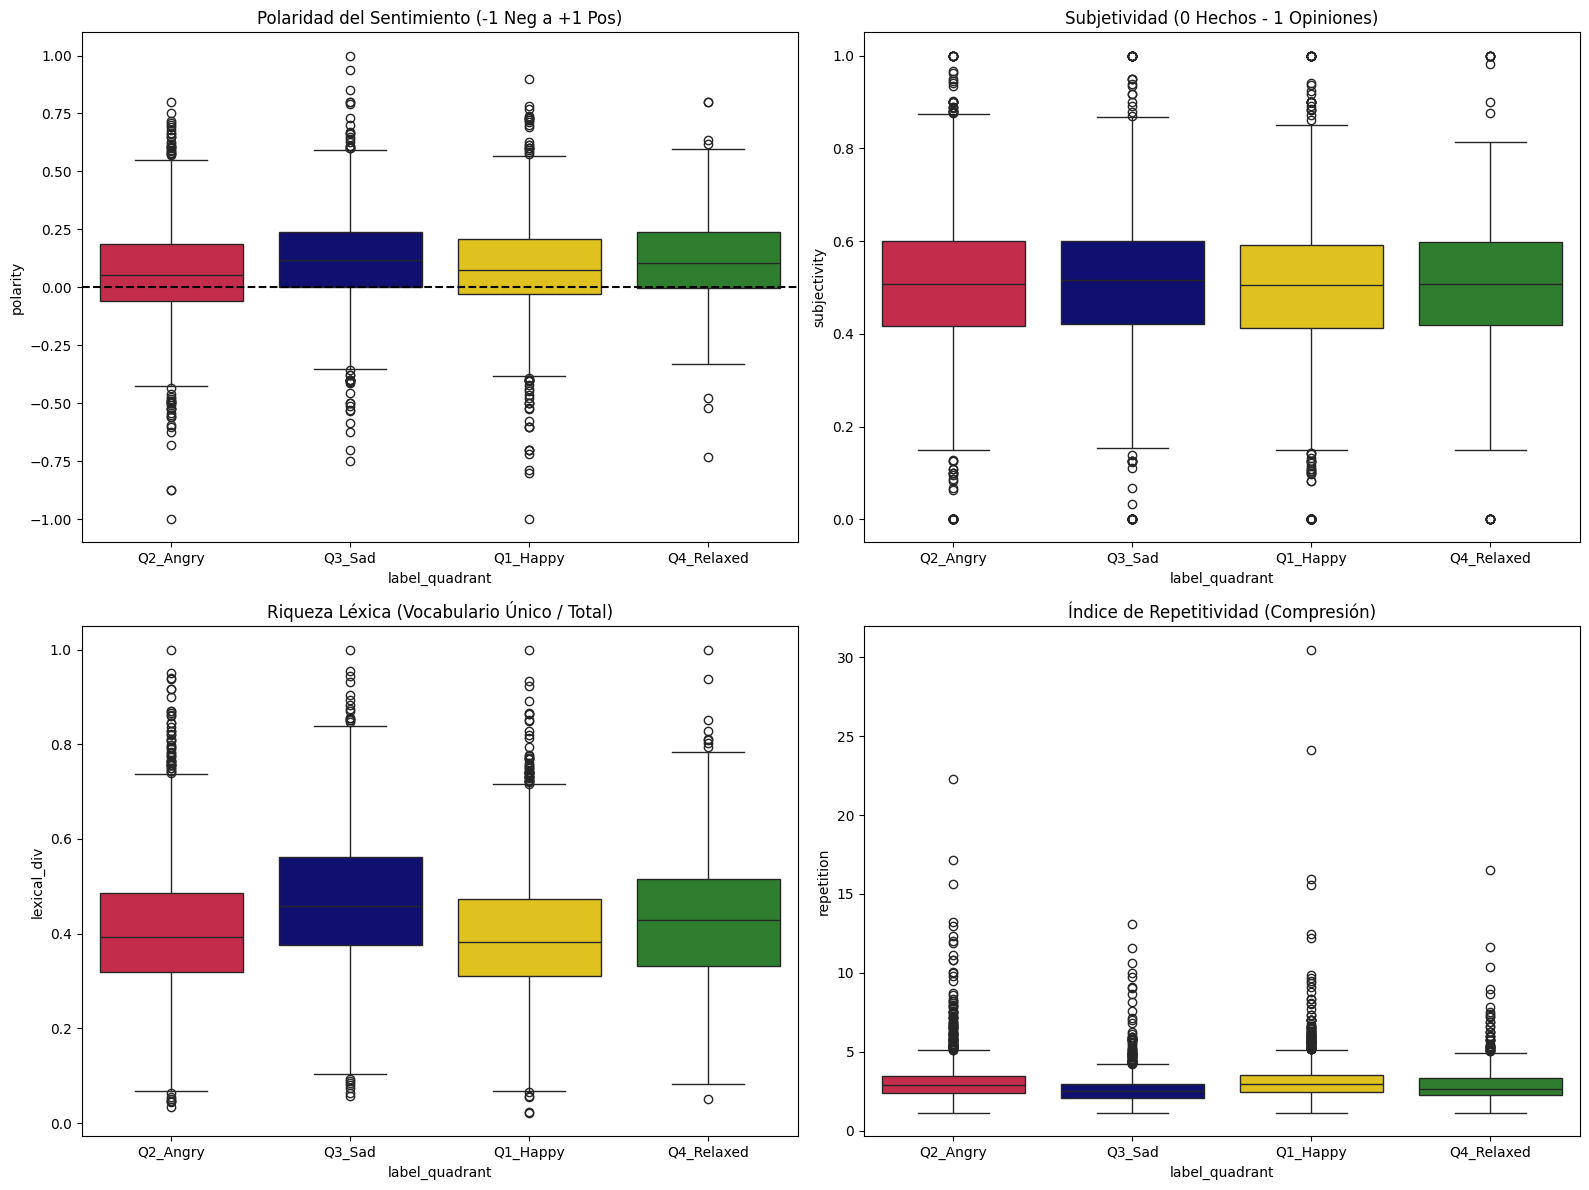

In [ ]:
# @title 2.6. Análisis Avanzado (Corregido para etiquetas de texto)
from textblob import TextBlob
import zlib
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("Calculando métricas avanzadas (Sentimiento y Estructura)...")

def calculate_metrics(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series([0, 0, 0, 0])

    blob = TextBlob(text)
    # 1. Sentimiento
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    # 2. Riqueza Léxica
    tokens = text.split()
    if len(tokens) == 0: return pd.Series([0, 0, 0, 0])
    lexical_diversity = len(set(tokens)) / len(tokens)

    # 3. Repetitividad
    compressed_len = len(zlib.compress(text.encode('utf-8')))
    compression_ratio = len(text) / (compressed_len + 1)

    return pd.Series([polarity, subjectivity, lexical_diversity, compression_ratio])

# Usamos la columna BERT o la que tengas disponible
target_col = 'clean_lyrics_bert' if 'clean_lyrics_bert' in df.columns else 'lyrics'
df[['polarity', 'subjectivity', 'lexical_div', 'repetition']] = df[target_col].fillna("").apply(calculate_metrics)

# --- VISUALIZACIÓN CORREGIDA ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Definir Diccionario de Colores basado en TUS etiquetas reales
# Asignamos colores según la emoción que dice el texto
colors = {
    'Q1_Happy': 'gold',       # Happy -> Amarillo/Dorado
    'Q2_Angry': 'crimson',    # Angry -> Rojo
    'Q3_Sad': 'navy',         # Sad -> Azul Oscuro
    'Q4_Relaxed': 'forestgreen' # Relaxed -> Verde
}

# Variable del eje X (ajusta si se llama 'quadrant' o 'label_quadrant')
x_col = 'label_quadrant' if 'label_quadrant' in df.columns else 'quadrant'

# --- GRÁFICA 1: Polaridad ---
# Nota: Agregamos hue=x_col y legend=False para evitar el Warning
sns.boxplot(x=x_col, y='polarity', data=df, ax=axes[0,0], palette=colors, hue=x_col, legend=False)
axes[0,0].set_title('Polaridad del Sentimiento (-1 Neg a +1 Pos)')
axes[0,0].axhline(0, color='k', linestyle='--')

# --- GRÁFICA 2: Subjetividad ---
sns.boxplot(x=x_col, y='subjectivity', data=df, ax=axes[0,1], palette=colors, hue=x_col, legend=False)
axes[0,1].set_title('Subjetividad (0 Hechos - 1 Opiniones)')

# --- GRÁFICA 3: Riqueza Léxica ---
sns.boxplot(x=x_col, y='lexical_div', data=df, ax=axes[1,0], palette=colors, hue=x_col, legend=False)
axes[1,0].set_title('Riqueza Léxica (Vocabulario Único / Total)')

# --- GRÁFICA 4: Repetitividad ---
sns.boxplot(x=x_col, y='repetition', data=df, ax=axes[1,1], palette=colors, hue=x_col, legend=False)
axes[1,1].set_title('Índice de Repetitividad (Compresión)')

plt.tight_layout()
plt.show()

## 2.6 Análisis de los Boxplots (Imagen 2)
Estos gráficos nos dicen qué tan "fáciles" o "difíciles" serán de distinguir las emociones usando solo estadísticas básicas.

    A. Polaridad del Sentimiento (Arriba-Izquierda):

    Observación: Las medianas (líneas horizontales dentro de las cajas) están todas muy cerca de 0.0 (Neutral).

    Interpretación: Esto confirma que el análisis de sentimiento simple (como TextBlob) NO es suficiente para clasificar música. Una canción "Happy" (Q1) puede tener una letra sarcástica o neutral, y una "Sad" (Q3) puede ser poética sin usar palabras explícitamente negativas.

    Conclusión: Necesitamos la red neuronal profunda (BERT) porque el sentimiento superficial no separa bien las clases.

    B. Subjetividad (Arriba-Derecha):

    Observación: Todas las cajas son idénticas y altas (> 0.5).

    Interpretación: Las letras de canciones son, por definición, opiniones y sentimientos personales (subjetivas).

    Conclusión: Esta métrica no discrimina entre emociones. No ayuda mucho al modelo.

    C. Riqueza Léxica (Abajo-Izquierda):

    Observación interesante: Fíjate en Q3_Sad (Azul oscuro). Su caja está ligeramente más arriba que Q1_Happy (Amarillo).

    Interpretación: Las canciones tristes tienden a usar un vocabulario más variado y complejo (narrativa). Las canciones felices (Pop/Dance) suelen repetir más las mismas palabras (coros pegajosos), por eso su riqueza es menor.

    Valor: Esta es una buena característica discriminante.

    D. Índice de Repetitividad (Abajo-Derecha) - ¡DATO CLAVE!:

    Observación: Mira la gran cantidad de puntos (outliers) en la parte superior de Q1_Happy (Amarillo) y Q2_Angry (Rojo).

    Interpretación: El cuadrante Happy tiene muchas canciones con alta compresión (mucha repetición). Esto es típico de los "hooks" del pop. El cuadrante Sad (Azul) es más plano.

Conclusión: La estructura repetitiva es una señal fuerte de alta energía (Happy/Angry).

Contando palabras (esto puede tardar unos segundos)...


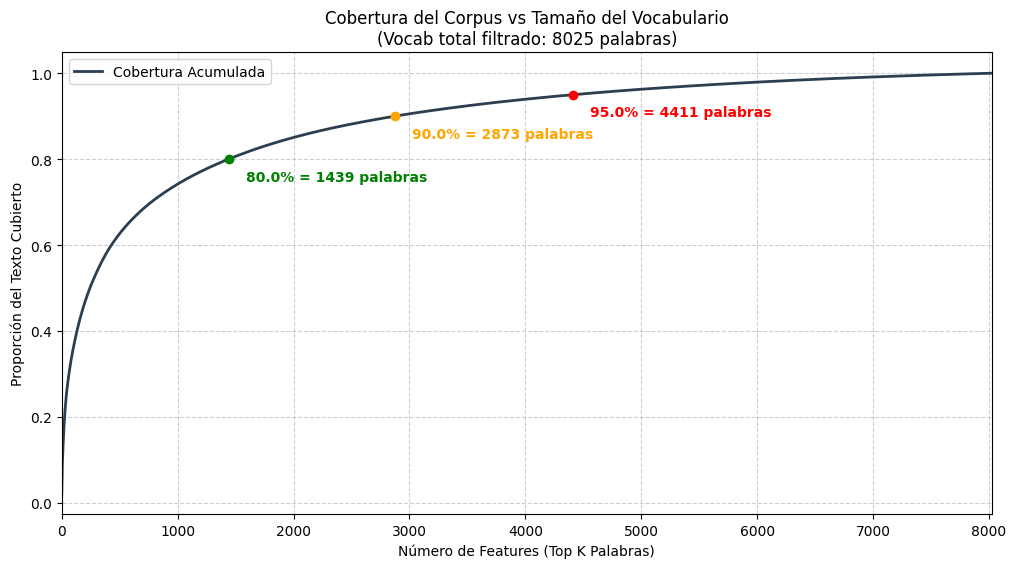


✅ RECOMENDACIÓN PARA TF-IDF:
Para capturar el 90% de la información semántica, usa max_features ≈ 2873


In [ ]:
# @title 3. Análisis de Cobertura de Vocabulario (TF-IDF)

# Usamos CountVectorizer para contar frecuencia pura de palabras
# min_df=5 elimina typos y palabras ultra-raras (ruido)
print("Contando palabras (esto puede tardar unos segundos)...")
cv = CountVectorizer(min_df=5, stop_words='english')
X = cv.fit_transform(df['clean_lyrics_tfidf'].fillna("").astype(str))

# Sumar frecuencias y ordenar de mayor a menor
word_freq = np.asarray(X.sum(axis=0)).flatten()
word_freq_sorted = np.sort(word_freq)[::-1]
total_tokens = word_freq_sorted.sum()

# Calcular cobertura acumulada
cumulative_coverage = np.cumsum(word_freq_sorted) / total_tokens

# --- GRAFICAR ---
plt.figure(figsize=(12, 6))
plt.plot(cumulative_coverage, linewidth=2, color='#2c3e50', label='Cobertura Acumulada')
plt.title(f'Cobertura del Corpus vs Tamaño del Vocabulario\n(Vocab total filtrado: {len(word_freq_sorted)} palabras)')
plt.xlabel('Número de Features (Top K Palabras)')
plt.ylabel('Proporción del Texto Cubierto')
plt.grid(True, linestyle='--', alpha=0.6)

# Buscar puntos de corte clave (80%, 90%, 95%)
colors = ['green', 'orange', 'red']
suggested_dim = 0

for i, target in enumerate([0.80, 0.90, 0.95]):
    # Encontrar índice donde cruzamos el umbral
    idx = np.searchsorted(cumulative_coverage, target)
    val = cumulative_coverage[idx]

    plt.plot(idx, val, 'o', color=colors[i])
    plt.text(idx + 150, val - 0.05, f'{target*100}% = {idx} palabras', fontsize=10, color=colors[i], fontweight='bold')

    # Guardamos el del 90% como sugerencia
    if target == 0.90: suggested_dim = idx

plt.xlim(0, min(10000, len(word_freq_sorted))) # Hacemos zoom en las primeras 10k
plt.legend()
plt.show()

print(f"\n✅ RECOMENDACIÓN PARA TF-IDF:")
print(f"Para capturar el 90% de la información semántica, usa max_features ≈ {suggested_dim}")

Estadísticas de longitud (número de palabras):
count    6455.000000
mean      266.982339
std       209.542086
min        12.000000
25%       168.000000
50%       239.000000
75%       324.000000
max      8823.000000
Name: word_count, dtype: float64


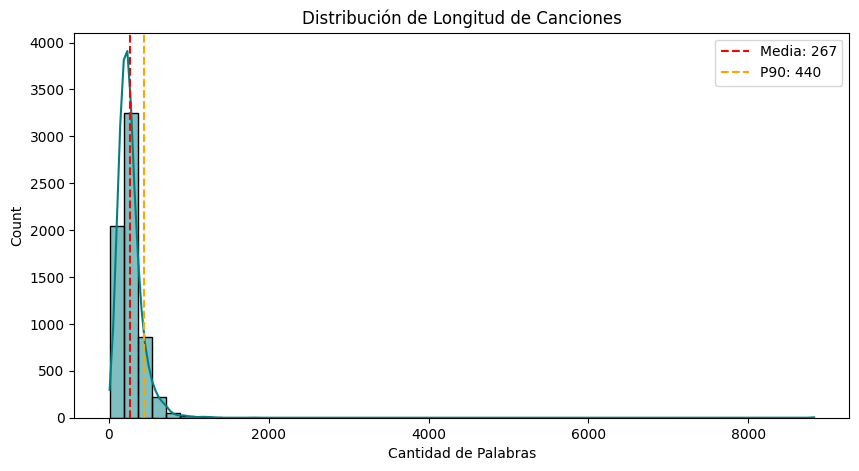


📚 Vocabulario Total Aproximado: 74456 palabras únicas


In [ ]:
# @title 3. Exploración de Longitud (Justificación para BERT)

# Contar palabras (usando la versión BERT que conserva estructura)
df['word_count'] = df['clean_lyrics_bert'].fillna("").apply(lambda x: len(str(x).split()))

# Estadísticas
print("Estadísticas de longitud (número de palabras):")
print(df['word_count'].describe())

# Histograma
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True, color='teal')
plt.axvline(df['word_count'].mean(), color='r', linestyle='--', label=f'Media: {df.word_count.mean():.0f}')
plt.axvline(df['word_count'].quantile(0.90), color='orange', linestyle='--', label=f'P90: {df.word_count.quantile(0.90):.0f}')
plt.title('Distribución de Longitud de Canciones')
plt.xlabel('Cantidad de Palabras')
plt.legend()
plt.show()

# Vocabulario
all_text = " ".join(df['clean_lyrics_bert'].fillna("").astype(str))
unique_words = set(all_text.split())
print(f"\n📚 Vocabulario Total Aproximado: {len(unique_words)} palabras únicas")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (815 > 512). Running this sequence through the model will result in indexing errors


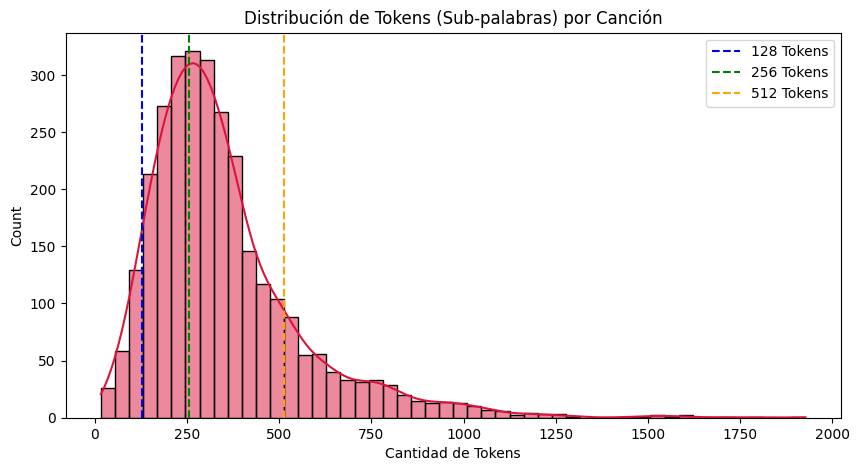

✅ Con MAX_LEN=128 cubres el 6.8% de las canciones completas.
✅ Con MAX_LEN=256 cubres el 36.9% de las canciones completas.
✅ Con MAX_LEN=512 cubres el 83.8% de las canciones completas.


In [ ]:
# @title 6. Análisis de Tokens de BERT (Justificación MAX_LEN)
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

token_lens = []
# Muestreamos 2000 canciones si son muchas para hacerlo rápido
sample_df = df.sample(min(3000, len(df)), random_state=42)

for txt in sample_df['clean_lyrics_bert'].fillna("").astype(str):
    # Tokenizamos sin cortar para ver el largo real
    tokens = tokenizer.encode(txt, truncation=False)
    token_lens.append(len(tokens))

plt.figure(figsize=(10, 5))
sns.histplot(token_lens, bins=50, kde=True, color='crimson')
plt.axvline(128, color='blue', linestyle='--', label='128 Tokens')
plt.axvline(256, color='green', linestyle='--', label='256 Tokens')
plt.axvline(512, color='orange', linestyle='--', label='512 Tokens')
plt.title('Distribución de Tokens (Sub-palabras) por Canción')
plt.xlabel('Cantidad de Tokens')
plt.legend()
plt.show()

cover_128 = sum([1 for x in token_lens if x <= 128]) / len(token_lens)
print(f"✅ Con MAX_LEN=128 cubres el {cover_128:.1%} de las canciones completas.")

cover_256 =sum([1 for x in token_lens if x <= 256]) / len(token_lens)
print(f"✅ Con MAX_LEN=256 cubres el {cover_256:.1%} de las canciones completas.")

cover_512=sum([1 for x in token_lens if x <= 512]) / len(token_lens)
print(f"✅ Con MAX_LEN=512 cubres el {cover_512:.1%} de las canciones completas.")


In [ ]:
# @title 7. Generación de Embeddings 2D (BERT)
import torch
from transformers import AutoModel

# --- PARÁMETROS ---
MAX_LEN = 256  # Ajustar según la gráfica anterior
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Procesando en: {device}")

# Cargar Modelo
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()

# Preparar datos
texts = df['clean_lyrics_bert'].fillna("").astype(str).tolist()
ids = df['spotify_id'].values

all_embeddings = []

print(f"Generando embeddings para {len(texts)} canciones...")

for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i : i + BATCH_SIZE]

    encoded = tokenizer(
        batch,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    with torch.no_grad():
        output = bert_model(input_ids, attention_mask=attention_mask)
        # Obtenemos la secuencia completa (Last Hidden State)
        # Shape: (Batch, 512, 768)
        emb = output.last_hidden_state.cpu().numpy()
        all_embeddings.append(emb)

# Concatenar
final_tensor = np.concatenate(all_embeddings, axis=0)
print(f"\n✅ Tensor Final: {final_tensor.shape}")

# GUARDAR
OUTPUT_DIR = Path("/content/drive/MyDrive/Proyecto Final MIR/features_2d/embeddings")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(OUTPUT_DIR / "embeddings_2d.npy", final_tensor)
np.save(OUTPUT_DIR / "embeddings_ids.npy", ids)

print(f"Archivos guardados en: {OUTPUT_DIR}")

Procesando en: cuda
Generando embeddings para 6455 canciones...

✅ Tensor Final: (6455, 256, 768)
Archivos guardados en: /content/drive/MyDrive/Proyecto Final MIR/features_2d/embeddings


In [ ]:
df.head()

,spotify_id,clean_lyrics_tfidf,clean_lyrics_bert,label_quadrant,valence,arousal,artist,track_name,polarity,subjectivity,lexical_div,repetition,word_count
0,1w8r3PAxPPLfcuyRsC4BeA,wanted stay away wanted run hide vows promises...,What if I wanted to stay away?\nWhat if I want...,Q2_Angry,0.225,0.858,Elysion,Made of Lies,0.309091,0.563636,0.323144,3.367164,229
1,6VeihScj0pNr6uGFxfzalq,gamble double dont step want stay youre bold r...,"It's a gamble, double down or don't\nStep out ...",Q2_Angry,0.327,0.976,Hot Water Music,Wayfarer,0.186296,0.523333,0.570552,2.166667,163
2,6HfUriaVuymw9EmYeG9WH5,could give life would take chance make see muc...,If I could give you life I would take the chan...,Q2_Angry,0.392,0.651,Grinspoon,Bleed You Dry,0.021050,0.587423,0.383673,3.229551,245
3,2zEcAdsl5OjxKRrGQA5Z49,save breath dont waste time ive got nothing le...,Save your breath\nDon't waste your time on me\...,Q2_Angry,0.200,0.932,VRSTY,Wilt,-0.068675,0.265256,0.326425,3.336842,386
4,0mJUxFpEI1eAOIIfnNoZ4G,im waiting cold cell bell begins chime reflect...,I'm waiting in my cold cell when the bell begi...,Q2_Angry,0.225,0.972,Cradle Of Filth,Hallowed Be Thy Name,-0.001723,0.532361,0.600000,2.012312,290


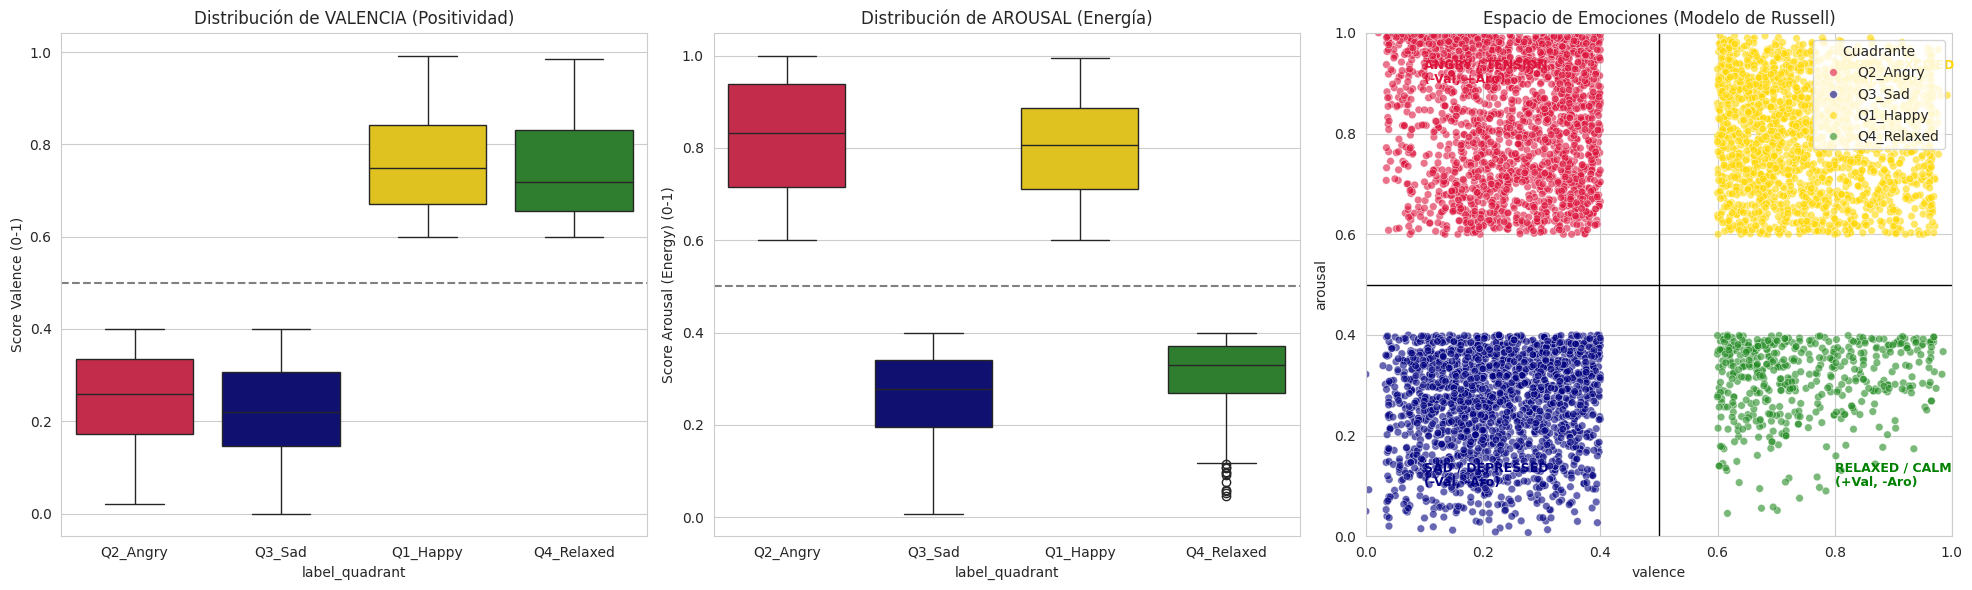

VALIDACIÓN:
Revisa los Boxplots:
- Happy y Relaxed deberían tener la caja de VALENCE alta (>0.5).
- Happy y Angry deberían tener la caja de AROUSAL alta (>0.5).


In [ ]:
# @title 9. Distribución de Valence y Arousal por Etiqueta
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- CORRECCIÓN AQUÍ: Usamos las etiquetas de TEXTO exactas ---
palette_colors = {
    'Q1_Happy': 'gold',       # Alto Valence, Alto Arousal
    'Q2_Angry': 'crimson',    # Bajo Valence, Alto Arousal
    'Q3_Sad': 'navy',         # Bajo Valence, Bajo Arousal
    'Q4_Relaxed': 'forestgreen' # Alto Valence, Bajo Arousal
}

# Variable del eje X
x_col = 'label_quadrant'

# --- GRÁFICA 1: Boxplot de VALENCE ---
# Agregamos hue=x_col y legend=False para cumplir con las nuevas normas de Seaborn
sns.boxplot(x=x_col, y='valence', data=df, ax=axes[0], palette=palette_colors, hue=x_col, legend=False)
axes[0].set_title('Distribución de VALENCIA (Positividad)')
axes[0].set_ylabel('Score Valence (0-1)')
axes[0].axhline(0.5, color='gray', linestyle='--')

# --- GRÁFICA 2: Boxplot de AROUSAL ---
sns.boxplot(x=x_col, y='arousal', data=df, ax=axes[1], palette=palette_colors, hue=x_col, legend=False)
axes[1].set_title('Distribución de AROUSAL (Energía)')
axes[1].set_ylabel('Score Arousal (Energy) (0-1)')
axes[1].axhline(0.5, color='gray', linestyle='--')

# --- GRÁFICA 3: Scatterplot (El Plano de Russell) ---
sns.scatterplot(
    x='valence', y='arousal',
    hue=x_col, data=df,
    palette=palette_colors, alpha=0.6, s=30, ax=axes[2]
)

# Dibujar las líneas del cuadrante
axes[2].axhline(0.5, color='black', linewidth=1)
axes[2].axvline(0.5, color='black', linewidth=1)
axes[2].set_title('Espacio de Emociones (Modelo de Russell)')
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].legend(loc='upper right', title='Cuadrante')

# Añadir etiquetas de texto a los cuadrantes (Ajustado a tus etiquetas Q1..Q4)
# Nota: Verifica si Q1 es Happy o Angry en tus datos.
# Generalmente: Q1(Happy), Q2(Angry), Q3(Sad), Q4(Relaxed)
# Pero a veces Q1 es Angry (Cuadrante II matemático).
# Ajusta el texto de abajo según lo que veas en la gráfica.

axes[2].text(0.1, 0.9, 'ANGRY / TENSION\n(-Val, +Aro)', fontsize=9, fontweight='bold', color='crimson')
axes[2].text(0.8, 0.9, 'HAPPY / EXCITED\n(+Val, +Aro)', fontsize=9, fontweight='bold', color='gold')
axes[2].text(0.1, 0.1, 'SAD / DEPRESSED\n(-Val, -Aro)', fontsize=9, fontweight='bold', color='navy')
axes[2].text(0.8, 0.1, 'RELAXED / CALM\n(+Val, -Aro)', fontsize=9, fontweight='bold', color='green')

plt.tight_layout()
plt.show()

print("VALIDACIÓN:")
print("Revisa los Boxplots:")
print("- Happy y Relaxed deberían tener la caja de VALENCE alta (>0.5).")
print("- Happy y Angry deberían tener la caja de AROUSAL alta (>0.5).")